In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

import joblib
import re
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("data/student_search_logs.csv")

df.head()

,session_id,searched_text,page_watch_duration
0,1340ad3a-9672-4489-8f27-9b1e8fe03db0,scientific calculator,69.80
1,84377312-199c-4391-ac3a-ba7b4e89bdd9,mini fridge,28.45
2,80dd3040-d37e-4842-a205-51b713903937,router,5.00
3,a394bc3a-354e-482f-bd45-a75d3bd096f8,DSA book,81.18
4,ebe8b547-11fc-4a5a-aeba-8a21bfdbfe86,power bank,42.97


In [5]:
df.describe()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           20000 non-null  str    
 1   searched_text        20000 non-null  str    
 2   page_watch_duration  20000 non-null  float64
dtypes: float64(1), str(2)
memory usage: 468.9 KB


In [6]:
threshold = df["page_watch_duration"].median()

df["search_success"] = np.where(
    df["page_watch_duration"] > threshold,
    1,
    0
)

df["search_success"].value_counts()

search_success
0    10003
1     9997
Name: count, dtype: int64

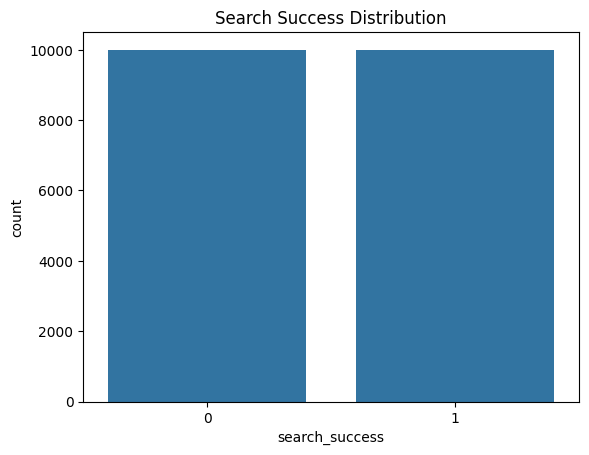

In [7]:
sns.countplot(x="search_success", data=df)
plt.title("Search Success Distribution")
plt.show()

In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

df["cleaned_text"] = df["searched_text"].apply(clean_text)

df.head()

,session_id,searched_text,page_watch_duration,search_success,cleaned_text
0,1340ad3a-9672-4489-8f27-9b1e8fe03db0,scientific calculator,69.80,1,scientific calculator
1,84377312-199c-4391-ac3a-ba7b4e89bdd9,mini fridge,28.45,0,mini fridge
2,80dd3040-d37e-4842-a205-51b713903937,router,5.00,0,router
3,a394bc3a-354e-482f-bd45-a75d3bd096f8,DSA book,81.18,1,dsa book
4,ebe8b547-11fc-4a5a-aeba-8a21bfdbfe86,power bank,42.97,0,power bank


In [9]:
vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1,2)
)

X_text = vectorizer.fit_transform(df["cleaned_text"])
y = df["search_success"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [12]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.72475

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.83      0.75      1990
           1       0.79      0.62      0.69      2010

    accuracy                           0.72      4000
   macro avg       0.74      0.73      0.72      4000
weighted avg       0.74      0.72      0.72      4000



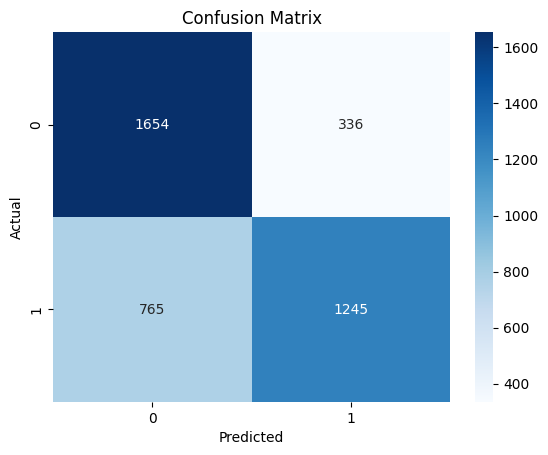

In [13]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
joblib.dump(model, "models/2/search_success_model.pkl")
joblib.dump(vectorizer, "models/2/tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [22]:
def predict_query(query):
    query_clean = clean_text(query)
    vector = vectorizer.transform([query_clean])
    
    probability = model.predict_proba(vector)[0][1]
    
    print(f"Query: {query}")
    print(f"Search Success Probability: {round(probability, 3)}")
    
    if probability > 0.6:
        print("Prediction: SUCCESS")
    elif probability < 0.4:
        print("Prediction: FAILURE")
    else:
        print("Prediction: UNCERTAIN (Low Confidence)")

In [27]:
predict_query("DSA book 3rd year")
predict_query("17 Pro Max phone")

Query: DSA book 3rd year
Search Success Probability: 0.75
Prediction: SUCCESS
Query: 17 Pro Max phone
Search Success Probability: 0.515
Prediction: UNCERTAIN (Low Confidence)
